# Data Collection

## Scrapping

### Install Library

In [2]:
!pip install google_play_scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00


### Import Library

In [3]:
import pandas as pd
from google_play_scraper import reviews, Sort
pd.set_option('display.max_colwidth', None)

### Google Play Store M-Pajak

In [4]:
result, continuation_token = reviews(
    'id.go.pajak.djp',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=5500)
df_playstore = pd.DataFrame(result)
df_playstore

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,d44deb8e-57f3-4ad3-8db2-9fac6791a889,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,terlalu dipersulit ada cara yg gampang ga biar lapor SPTnya juga cepat,2,0,3.0.10,2026-07-27 11:44:29,None,None,3.0.10
1,5142d8cc-d692-44e0-a139-44e162a13da3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,aplikasi malah banyak BUG. bisa bocor data kalau begini.,1,0,3.0.10,2026-07-27 11:39:06,None,None,3.0.10
2,b17bcbe0-4fc7-4d61-b5cf-6a10f175d810,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,konyol aplikasinya waktu log-in aja error mulu alasanya pihak ketiga,1,0,None,2026-07-27 11:02:47,None,None,None
3,7fb3ddca-abe1-4c8c-a316-38e9293c41a3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"plis deh ini lemot nya ngelemottttttt bangettt kek bener bener di persulitt sama ni apkkkk, benerin dulu apk nya ga usah fokus sama fitur lainnya yang penting lancarrrr pembuatan NPWP kalo g butuh buat kerjaan ga bakal ku pake ni apk",1,0,3.0.10,2026-07-27 09:35:42,None,None,3.0.10
4,9794d175-0414-462b-9662-738425145efb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"heran, aplikaai yang diurus pemerintah kenapa selalu jelek. coba cari yang bekompeten.",1,0,None,2026-07-27 05:51:06,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...
5495,b895bcb8-f0d8-4cd6-a132-60400d484203,Ahmad Saroni 74,https://play-lh.googleusercontent.com/a-/ALV-UjUlbkWbNymX_CPC_KkaAN3BsMnqEOWYWo1riuiTDgaof6OFPMNI,"Susah ,ruwet,ribet,angel...bikin pusing tambah pusing 😇😇😇",1,0,1.3.0,2024-02-03 15:06:43,None,None,1.3.0
5496,a1410af8-ac2d-4873-b209-204481870409,Parta Andika,https://play-lh.googleusercontent.com/a/ACg8ocLdCkKCwy27ErqUjDr8tm28sdXU9cQSyZElF5-bsMWBuh3KJQ=mo,Aplikasi ga jelas,1,0,1.3.0,2024-02-03 11:59:59,None,None,1.3.0
5497,6eab9dfe-1050-4899-bd7b-b99bd1dceb6b,Hady Anto,https://play-lh.googleusercontent.com/a-/ALV-UjXhJWQ35Ri7DjVWWCynBShwTVtsO_6zyFNBdaTCv_lraBNPVX-v,Aplikasi hanya bisa melihat saja tidak bisa mengisi laporan pajak,3,0,1.3.0,2024-02-02 19:09:39,None,None,1.3.0
5498,e1a1a1a8-f938-4fac-8c9e-b8283baec77b,ADITYA AHMAD NUGRAHA,https://play-lh.googleusercontent.com/a-/ALV-UjWzKnRBK0vMwz1sL4n9ykw12lnd1n-04pOKBX5fUntha3X7eEqg,Oi benerin sistem aplikasinya jelek bener gua bayar pajak tapi kok aplikasinya jelek bener,1,0,1.3.0,2024-02-02 10:50:45,None,None,1.3.0


### Download Data

In [5]:
df_playstore.to_csv("mpajak.csv", index=False, encoding='utf-8-sig')



---



## Sentiment Analysis

### Install Library

In [6]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.5 MB/s eta 0:00:00


In [7]:
!pip install transformers torch

### Import Library

In [8]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import nltk
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import nltk
import nltk
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
import string
import nltk
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
import nltk
from nltk.corpus import stopwords as nltk_stopwords

nltk.download('punkt')
nltk.download('stopwords')

stopword_id = set(nltk_stopwords.words('indonesian'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### Read Data

In [9]:
df = pd.read_csv("https://raw.githubusercontent.com/hastisf/sentimentanalysis/main/Project%20Sentiment/Data/Raw/mpajak.csv")
#df = pd.read_csv("mpajak.csv")
df.head(10)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,cab8833d-1a50-4a13-8e2b-7f511806f6f6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,mantaffff....baik,5,0,2.0.6,2026-07-05 01:40:21,NaN,NaN,2.0.6
1,8abb3970-d2cd-4384-ac92-fcbcb0a784e5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,mohon di tambahkan fitur lainnya,1,0,NaN,2026-07-04 21:36:00,NaN,NaN,NaN
2,aaeb15af-6828-40e9-8b72-8c5ca1dd49e7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"aplikasi sampah , error teros ,,",1,0,3.0.10,2026-07-04 06:15:23,NaN,NaN,3.0.10
3,1efc63f3-4ad0-4c43-91ff-e1335cd0f9aa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,ini mau daftar susah amat gak dilaptop sama di hp. yang bener lah kalo kita disuruh bayar pajak. sistemnya gimana nih kalo kita gak bisa bayar. kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,1,0,3.0.10,2026-07-04 06:14:00,NaN,NaN,3.0.10
4,7f3792a4-e142-4bac-9a47-c8ceb7451f0d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,Apk bodoh..,1,0,3.0.10,2026-07-04 03:28:51,NaN,NaN,3.0.10
5,88024fe3-0274-4802-8094-79ab425b60fc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,aplikasi error,1,0,3.0.10,2026-07-04 01:27:54,NaN,NaN,3.0.10
6,cb683c78-83e8-4259-93b5-23b40a0ea916,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,aku pikir bisa bayar pajak di aplikasi ini. setelah aktifasi gak jelas ini aplikasi. aku liat retting nya semua sama,5,0,NaN,2026-07-04 00:13:05,NaN,NaN,NaN
7,e10fad32-cb13-42be-9f92-f60ef2c9d890,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,APLIKASI PARAH,1,0,3.0.10,2026-07-03 15:50:36,NaN,NaN,3.0.10
8,ec74860a-bfd5-4a54-8d70-6417a8da5d4b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,ga niat buat aplikasi nyusahin,1,0,NaN,2026-07-03 11:52:56,NaN,NaN,NaN
9,61e843fd-7619-4bf0-bbd5-9fe98abe6be0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,aplikasi tertaiiiiiiiiii.... mempersulit rakyat kecillllllll..,1,0,3.0.10,2026-07-03 09:29:24,NaN,NaN,3.0.10


### Ambil Kolom Content

In [10]:
df = df[['content']].copy()

# EDA

## Data Information

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  5500 non-null   object
dtypes: object(1)
memory usage: 43.1+ KB


##Missing Value

In [12]:
df.isnull().sum()

,0
content,0


## Duplicate

In [13]:
df.duplicated().sum()

np.int64(444)

## Drop Duplicate

In [14]:
df = df.drop_duplicates()

## Data Statistic

In [15]:
df.describe()

,content
count,5056
unique,5056
top,"Aplikasinya parah banget, sama sekali tidak bisa login😡😡😡😡😡"
freq,1


## Simple Visualization

### Raw Rating Distribution - Bar Chart

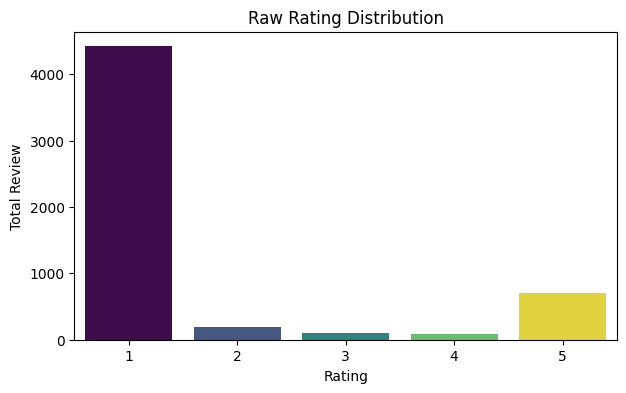

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.countplot(data=df_playstore, x='score', palette='viridis', hue='score', legend=False)
plt.title('Raw Rating Distribution', fontsize=12)
plt.xlabel('Rating')
plt.ylabel('Total Review')
plt.show()

### Tren Volume Ulasan Per Bulan - Line Chart

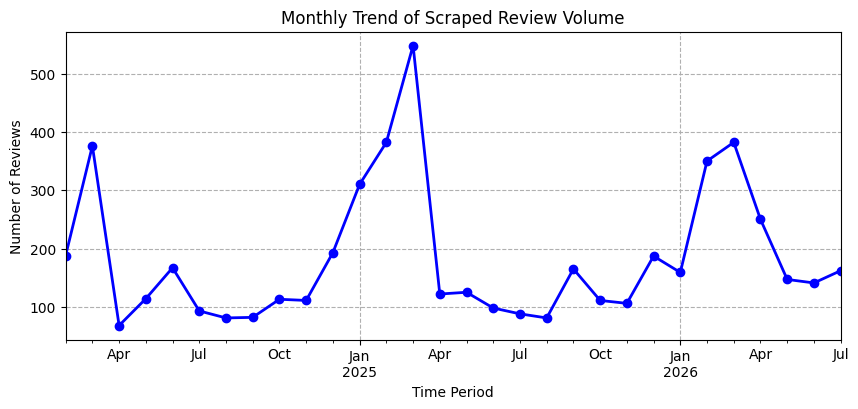

In [17]:
# Konversi kolom 'at' ke datetime dan set tren per bulan
df_playstore['at'] = pd.to_datetime(df_playstore['at'])
monthly_reviews = df_playstore.groupby(df_playstore['at'].dt.to_period('M')).size()

plt.figure(figsize=(10, 4))
monthly_reviews.plot(kind='line', marker='o', color='b', linewidth=2)
plt.title('Monthly Trend of Scraped Review Volume', fontsize=12)
plt.xlabel('Time Period')
plt.ylabel('Number of Reviews')
plt.grid(True, linestyle='--')
plt.show()

### Distribution of Review Length in Characters - Histogram

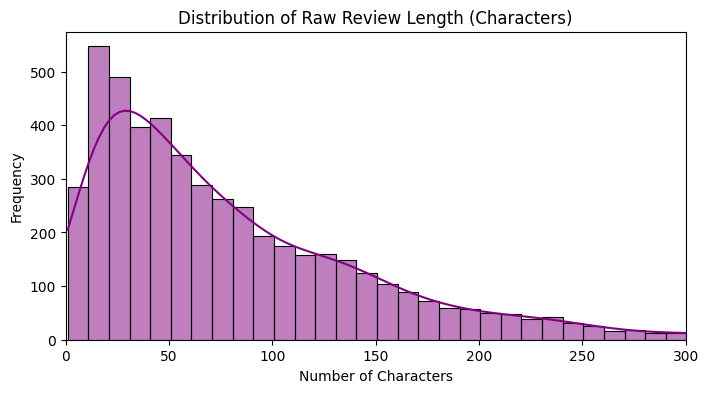

In [18]:
plt.figure(figsize=(8, 4))
# Menghitung panjang karakter dari teks mentah
raw_lengths = df['content'].dropna().str.len()

sns.histplot(raw_lengths, bins=50, kde=True, color='purple')
plt.title('Distribution of Raw Review Length (Characters)', fontsize=12)
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.xlim(0, 300) # Batasi limit -> grafik tidak condong jika teks sangat panjang
plt.show()

### Top 5 Most Reviewed App Versions - Bar Chart

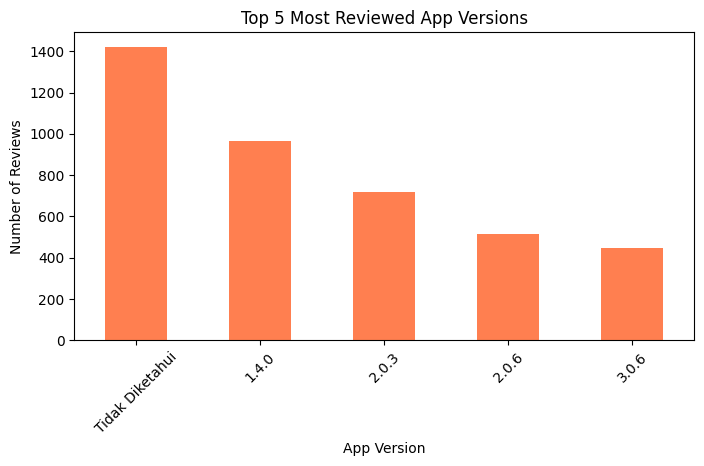

In [19]:
plt.figure(figsize=(8, 4))
# Mengambil 5 versi teratas dan menangani missing value dengan fillna
df_playstore['appVersion'].fillna(
    'Tidak Diketahui').value_counts().head(5).plot(kind='bar', color='coral')

plt.title('Top 5 Most Reviewed App Versions', fontsize=12)
plt.xlabel('App Version')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.show()

Proportion of Developer Responses to Reviews - Pie Chart

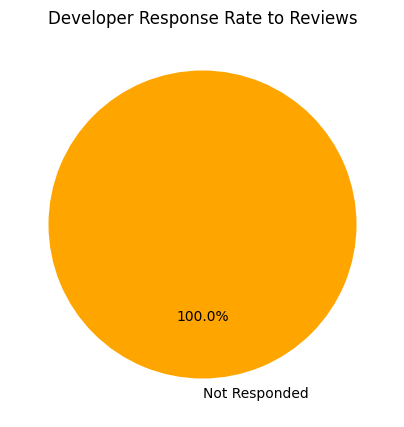

In [20]:
plt.figure(figsize=(5, 5))
# Cek apakah kolom replyContent kosong atau ada isinya
reply_status = df_playstore['replyContent'].isnull().map({
    True: 'Not Responded',
    False: 'Responded'
}).value_counts()

plt.pie(
    reply_status,
    labels=reply_status.index,
    autopct='%1.1f%%',
    colors=['orange', 'gold'],
    startangle=90
)

plt.title('Developer Response Rate to Reviews', fontsize=12)
plt.show()

# Data Preprocessing

## Cleaning

In [21]:
def cleaning(content):

    content = str(content)

    # remove URL
    content = re.sub(r'http\S+|www\S+|https\S+', '', content)

    # remove mention
    content = re.sub(r'@\w+', '', content)

    # remove hashtag
    content = re.sub(r'#\w+', '', content)

    # subtitute dot become space
    content = content.replace('.', ' ')

    # subtitute underscore
    content = content.replace('_', ' ')

    # remove number
    content = re.sub(r'\d+', '', content)

    # remove emoji
    content = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        '',
        content,
        flags=re.UNICODE
    )

    # replace punctuation with space instead of removing it
    for punct in string.punctuation:
        content = content.replace(punct, ' ')

    # remove special characters
    content = re.sub(r'[^a-zA-Z\s]', ' ', content)

    # remove excess space
    content = re.sub(r'\s+', ' ', content).strip()

    return content

# Pakai .loc[:, 'cleaning'] untuk menghindari SettingWithCopyWarning
df.loc[:, 'cleaning'] = df['content'].apply(cleaning)

In [22]:
df.head()

,content,cleaning
0,mantaffff....baik,mantaffff baik
1,mohon di tambahkan fitur lainnya,mohon di tambahkan fitur lainnya
2,"aplikasi sampah , error teros ,,",aplikasi sampah error teros
3,ini mau daftar susah amat gak dilaptop sama di hp. yang bener lah kalo kita disuruh bayar pajak. sistemnya gimana nih kalo kita gak bisa bayar. kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang
4,Apk bodoh..,Apk bodoh


In [23]:
df.tail()

,content,cleaning
5495,"Min, data alamat kok nggak bisa diganti, padahal sudah pindah alamat 😂😂😂",Min data alamat kok nggak bisa diganti padahal sudah pindah alamat
5496,"Katanya ngisi no NPWP atau Nik, ketika isi NIK tidak bisa karena hanya bisa 15 digit",Katanya ngisi no NPWP atau Nik ketika isi NIK tidak bisa karena hanya bisa digit
5497,Gak bisa download,Gak bisa download
5498,"Saya baru mau daftar, pas udh tahap 2 trs tiba2 keluar sendiri, pas coba login lagi gak bisa karena userid dan ps salah, padahal udh bener, trs coba bikin lagi pake email yang sama gak bisa karena udah digunakan, gmna solusi nya? Saya mau ttp pakai email sebelumnya",Saya baru mau daftar pas udh tahap trs tiba keluar sendiri pas coba login lagi gak bisa karena userid dan ps salah padahal udh bener trs coba bikin lagi pake email yang sama gak bisa karena udah digunakan gmna solusi nya Saya mau ttp pakai email sebelumnya
5499,Tidak ada riwayat pembayaran ya???. Saya mau screen shoot buat lapor SPT. Jika di browser chorme juga tidak bisa muncul keterangan tidak di temukan. Tolong dong perbaiki dengan baik,Tidak ada riwayat pembayaran ya Saya mau screen shoot buat lapor SPT Jika di browser chorme juga tidak bisa muncul keterangan tidak di temukan Tolong dong perbaiki dengan baik


## Preparing Text for IndoBERT Labeling

In [24]:
def preprocess_label(text):
    return str(text).lower().strip()

df["label_text"] = df["cleaning"].apply(preprocess_label)

# Sentiment Labeling

In [25]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="mdhugol/indonesia-bert-sentiment-classification"
)

config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [26]:
labels = []
scores = []

for text in df["label_text"]:

    if pd.notnull(text):

        result = classifier(str(text))[0]

        labels.append(result["label"])
        scores.append(result["score"])

    else:

        labels.append("unknown")
        scores.append(0)

df["sentiment"] = labels
df["sentiment_score"] = scores

In [27]:
label_mapping = {
    "LABEL_0": "Positive",
    "LABEL_1": "Neutral",
    "LABEL_2": "Negative"
}

labels = []
scores = []

for text in df["label_text"]:

    if pd.notnull(text):

        result = classifier(str(text))[0]

        labels.append(label_mapping[result["label"]])
        scores.append(result["score"])

    else:

        labels.append("Unknown")
        scores.append(0)

df["sentiment"] = labels
df["sentiment_score"] = scores

# Text Preprocessing ML

## Case Folding

In [28]:
# Menyeragamkan hurus menjadi lowercase

def case_folding(content):
    if isinstance(content,str):
        lowercase_content = content.lower()
        return lowercase_content
    else:
        return content
df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(10)

,content,cleaning,label_text,sentiment,sentiment_score,case_folding
0,mantaffff....baik,mantaffff baik,mantaffff baik,Positive,0.995123,mantaffff baik
1,mohon di tambahkan fitur lainnya,mohon di tambahkan fitur lainnya,mohon di tambahkan fitur lainnya,Neutral,0.995181,mohon di tambahkan fitur lainnya
2,"aplikasi sampah , error teros ,,",aplikasi sampah error teros,aplikasi sampah error teros,Negative,0.995990,aplikasi sampah error teros
3,ini mau daftar susah amat gak dilaptop sama di hp. yang bener lah kalo kita disuruh bayar pajak. sistemnya gimana nih kalo kita gak bisa bayar. kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi ampe siang,Negative,0.993020,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi ampe siang
4,Apk bodoh..,Apk bodoh,apk bodoh,Negative,0.998063,apk bodoh
5,aplikasi error,aplikasi error,aplikasi error,Negative,0.995911,aplikasi error
6,aku pikir bisa bayar pajak di aplikasi ini. setelah aktifasi gak jelas ini aplikasi. aku liat retting nya semua sama,aku pikir bisa bayar pajak di aplikasi ini setelah aktifasi gak jelas ini aplikasi aku liat retting nya semua sama,aku pikir bisa bayar pajak di aplikasi ini setelah aktifasi gak jelas ini aplikasi aku liat retting nya semua sama,Neutral,0.802110,aku pikir bisa bayar pajak di aplikasi ini setelah aktifasi gak jelas ini aplikasi aku liat retting nya semua sama
7,APLIKASI PARAH,APLIKASI PARAH,aplikasi parah,Negative,0.997738,aplikasi parah
8,ga niat buat aplikasi nyusahin,ga niat buat aplikasi nyusahin,ga niat buat aplikasi nyusahin,Negative,0.997073,ga niat buat aplikasi nyusahin
9,aplikasi tertaiiiiiiiiii.... mempersulit rakyat kecillllllll..,aplikasi tertaiiiiiiiiii mempersulit rakyat kecillllllll,aplikasi tertaiiiiiiiiii mempersulit rakyat kecillllllll,Negative,0.974681,aplikasi tertaiiiiiiiiii mempersulit rakyat kecillllllll


In [29]:
df[["content", "sentiment", "sentiment_score"]].head(10)

,content,sentiment,sentiment_score
0,mantaffff....baik,Positive,0.995123
1,mohon di tambahkan fitur lainnya,Neutral,0.995181
2,"aplikasi sampah , error teros ,,",Negative,0.995990
3,ini mau daftar susah amat gak dilaptop sama di hp. yang bener lah kalo kita disuruh bayar pajak. sistemnya gimana nih kalo kita gak bisa bayar. kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,Negative,0.993020
4,Apk bodoh..,Negative,0.998063
5,aplikasi error,Negative,0.995911
6,aku pikir bisa bayar pajak di aplikasi ini. setelah aktifasi gak jelas ini aplikasi. aku liat retting nya semua sama,Neutral,0.802110
7,APLIKASI PARAH,Negative,0.997738
8,ga niat buat aplikasi nyusahin,Negative,0.997073
9,aplikasi tertaiiiiiiiiii.... mempersulit rakyat kecillllllll..,Negative,0.974681


In [30]:
df["sentiment"].value_counts()

,count
sentiment,
Negative,4069
Neutral,524
Positive,463


##Tokenization

In [31]:
# Memisahkan kalimat menjadi potongan kata

def tokenize(content):
    tokens = content.split()
    return tokens
df['tokenize'] = df['case_folding'].apply(tokenize)
df.head(10)

,content,cleaning,label_text,sentiment,sentiment_score,case_folding,tokenize
0,mantaffff....baik,mantaffff baik,mantaffff baik,Positive,0.995123,mantaffff baik,"[mantaffff, baik]"
1,mohon di tambahkan fitur lainnya,mohon di tambahkan fitur lainnya,mohon di tambahkan fitur lainnya,Neutral,0.995181,mohon di tambahkan fitur lainnya,"[mohon, di, tambahkan, fitur, lainnya]"
2,"aplikasi sampah , error teros ,,",aplikasi sampah error teros,aplikasi sampah error teros,Negative,0.995990,aplikasi sampah error teros,"[aplikasi, sampah, error, teros]"
3,ini mau daftar susah amat gak dilaptop sama di hp. yang bener lah kalo kita disuruh bayar pajak. sistemnya gimana nih kalo kita gak bisa bayar. kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi ampe siang,Negative,0.993020,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi ampe siang,"[ini, mau, daftar, susah, amat, gak, dilaptop, sama, di, hp, yang, bener, lah, kalo, kita, disuruh, bayar, pajak, sistemnya, gimana, nih, kalo, kita, gak, bisa, bayar, kocak, kali, lah, mau, daftar, gak, bisa, diakses, dari, pagi, ampe, siang]"
4,Apk bodoh..,Apk bodoh,apk bodoh,Negative,0.998063,apk bodoh,"[apk, bodoh]"
5,aplikasi error,aplikasi error,aplikasi error,Negative,0.995911,aplikasi error,"[aplikasi, error]"
6,aku pikir bisa bayar pajak di aplikasi ini. setelah aktifasi gak jelas ini aplikasi. aku liat retting nya semua sama,aku pikir bisa bayar pajak di aplikasi ini setelah aktifasi gak jelas ini aplikasi aku liat retting nya semua sama,aku pikir bisa bayar pajak di aplikasi ini setelah aktifasi gak jelas ini aplikasi aku liat retting nya semua sama,Neutral,0.802110,aku pikir bisa bayar pajak di aplikasi ini setelah aktifasi gak jelas ini aplikasi aku liat retting nya semua sama,"[aku, pikir, bisa, bayar, pajak, di, aplikasi, ini, setelah, aktifasi, gak, jelas, ini, aplikasi, aku, liat, retting, nya, semua, sama]"
7,APLIKASI PARAH,APLIKASI PARAH,aplikasi parah,Negative,0.997738,aplikasi parah,"[aplikasi, parah]"
8,ga niat buat aplikasi nyusahin,ga niat buat aplikasi nyusahin,ga niat buat aplikasi nyusahin,Negative,0.997073,ga niat buat aplikasi nyusahin,"[ga, niat, buat, aplikasi, nyusahin]"
9,aplikasi tertaiiiiiiiiii.... mempersulit rakyat kecillllllll..,aplikasi tertaiiiiiiiiii mempersulit rakyat kecillllllll,aplikasi tertaiiiiiiiiii mempersulit rakyat kecillllllll,Negative,0.974681,aplikasi tertaiiiiiiiiii mempersulit rakyat kecillllllll,"[aplikasi, tertaiiiiiiiiii, mempersulit, rakyat, kecillllllll]"


## Slang Normalization

In [32]:
slang_dict = {
    'abal':'abal-abal','abalabal':'abal-abal','abdet':'update',
    'aflikasi':'aplikasi','aj':'saja','aja': 'saja', 'ajaa': 'saja',
    'ajah': 'saja', 'ajalah': 'saja', 'ajg': 'anjing', 'ajh': 'saja',
    'ajha': 'saja', 'aktik': 'aktif', 'aktifasi': 'aktivasi',
    'ampee':'sampai','ampe': 'sampai','ampas': 'ampas',
    'ampaslah': 'ampas', 'ampunnn':'ampun','ancur': 'hancur',
    'anj': 'anjing','anjengggg': 'anjing', 'anjg':'anjing','anjir': 'anjing',
    'anjggg': 'anjing',
    'anjr':'anjing','anjrit': 'anjing', 'anying': 'anjing',
    'anyinh': 'anjing','anyingg': 'anjing','anjim' : 'anjing',
    'anjay' : 'anjing', 'anjr' : 'anjing', 'anying' : 'anjing',
    'anyingg' : 'anjing','apa2':'apa apa',
    'apaansi': 'apaan sih','apk': 'aplikasi', 'apkikasinya':'aplikasinya',
    'apkn':'aplikasi','apknya':'aplikasi','aplikaainya':'aplikasinya',
    'aplikasih':'aplikasi','app': 'aplikasi','apps':'aplikasi',
    'aps':'aplikasi','awikwok':'tertawa' ,'bae':'saja',
    'baget': 'banget', 'bagus':'bagus', 'bagusan': 'bagus',
    'banyakkk': 'banyak','bangke':'banget','bapuk':'jelek',
    'berjam2': 'berjam-jam', 'berkali': 'berkali-kali',
    'berteletele': 'tidak jelas', 'bgtt': 'banget', 'bgt':'banget',
    'bgttt':'banget','bgus':'bagus','bikan':'bikin','bikin':'membuat',
    'bkin':'membuat','blm':'belum','bnget':'banget','bngtt':'banget',
    'bngung':'bingung','bnyk':'banyak','bnyak':'banyak',
   'boncos': 'rugi', 'boro2': 'boro-boro', 'br':'benar',
    'broken':'rusak','bungol': 'bodoh', 'burik':'buruk','busok':'busuk',
    'butut': 'buruk', 'byr': 'bayar','cacad': 'cacat',
    'capslock': 'caps lock', 'capecape': 'capek capek', 'cht': 'chat',
    'cipatin': 'ciptain', 'cokkkkk': 'cuk', 'coraetax': 'coretax',
    'coretak':'coretax','coretex':'coretax','cortec':'coretax',
    'cortes':'coretax','cortetak':'coretax','cortex':'coretax',
    'coretek':'coretax','coretak':'coretax','crhome':'chrome','crome':'chrome',
    'dapt':'dapat','daptar':'daftar','dateng':'datang','dbuat':'dibuat',
    'dgn':'dengan','dikirim2':'dikirim','dikirim"': 'dikirim',
    'dimasukan': 'dimasukkan','ditanyain':'ditanyakan','dongo': 'dongo',
    'dwld': 'download', 'eefin':'efin', 'efein': 'efin','effin': 'efin',
    'efiin': 'efin', 'efin': 'efin', 'efrin': 'efin', "efinnya":"efin",
    'elek': 'jelek', 'emang': 'memang','emg': 'memang', 'emprottt': 'emprot',
    'engga': 'tidak', 'enggak': 'tidak','eror': 'error', 'erro':'error',
    'erorr': 'error', 'errrror': 'error', 'errorrr': 'error', 'erroor':'error',
    "errorr":"error",'evin': 'efin', "cras":"crash", 'crashh':'crash',
    'kadaluarasa':'kedaluwarsa','expired':'kedaluwarsa',"force-close":"forceclose",
    'force close':'forceclose','g':'tidak','gagal':'gagal', 'gaje':'tidak jelas',
    'gajelas': 'tidak jelas', "kadaluarsa":"kedaluwarsa",
    'gajlss': 'tidak jelas', 'gblk': 'goblok', 'gada': 'tidak ada',
    "gagalnya":"gagal",'gae': 'membuat','gaguna': 'tidak berguna',
    'gajadi':'tidak jadi', 'fc':'forceclose','gbs': 'tidak bisa','gedeg':'kesal',
    'ghoblok': 'goblok', 'ginii': 'gini','gmn': 'bagaimana', 'gmna':'bagaimana',
    'goblk':'goblok','goblokk': 'goblok','good': 'bagus', 'gtw': 'gak tahu',
    'hacehhh': 'haduh','jdi': 'jadi', 'jelass': 'jelas','jink':'anjing',
    'josss': 'jos', 'kagak': 'tidak', 'kacao': 'kacau', 'kalo': 'kalau',
    'karna': 'karena', 'karnaa': 'karena','kek': 'kayak', 'kekick': 'keluar',
    'kemkeu': 'Kemenkeu', 'kentir': 'aneh', 'kg': 'tidak','kgk': 'tidak',
    'kl': 'kalau', 'klu': 'kalau', 'klau': 'kalau', 'kliatan': 'kelihatan',
    'knp': 'kenapa', 'kompirmasi': 'konfirmasi','konoha': 'indonesia',
    'kortek':'coretax' ,'krg':'kurang','krn': 'karena', 'kyk': 'seperti',
    'lag': 'lag', "lagg":"lag",'lemott': 'lemot','lemottt': 'lemot',
    'loginbgak':'login','loginbug':'login bug', "loginin":"login",
    'loging': 'login', 'loginnya': 'login','loginn': 'login', "logoutnya":"logout",
    'main2': 'main-main', 'maintenis': 'maintenance','makasih': 'terima kasih',
    'makasi': 'terima kasih', 'mantaffff': 'mantap', 'mantaaap': 'mantap',
    "mantaaapp":"mantap",'mantapp':'mantap','mantappp':'mantap','manthaafff':'mantap',
    'masukin': 'memasukkan','matap': 'mantap','melulu':'terus','menti':'menit',
    'mulu': 'terus', 'muluu': 'terus','muluuu': 'terus',
    'musti': 'mesti', 'naajissss': 'najis','ngebang':'hang','ngebug':'bug',
    'ngelag':'lag','ngelaggg': 'lag', 'ngga': 'tidak', 'nggak': 'tidak',
    'nggk': 'tidak','ngisinya': 'mengisinya', 'ngisi': 'mengisi',
    'nipurakyat': 'tipu rakyat', 'no': 'nomor', 'nomot': 'nomor',
    'notif': 'notifikasi', 'notivikasi': 'notifikasi', 'nyari': 'mencari',
    'nyimpen': 'menyimpan', 'nyusahin': 'menyusahkan', 'okee': 'oke',
    'orng²':'orang-orang','otw':'menuju','pajakk':'pajak','pantesan':'pantas',
    'pasword': 'password','pencet': 'tekan','pisann':'pisan',
    'plis': 'please', 'plisa': 'please', 'polri': 'polri',
    'prematur': 'belum matang', 'prik': 'aneh', 'rata2': 'rata-rata',
    'regestrasi': 'registrasi' , 'ribettt': 'ribet', 'sampe': 'sampai',
    'samsek': 'sama sekali','stuk': 'stuck', 'suport': 'support', 'sush':'susah',
    'susahh': 'susah','sussah': 'susah','taii':'tai','taiiii':'tai','tataian':'tai',
    'telfon': 'telepon','temen²':'teman-teman', 'teross':'terus','th':'tahun',
    'thn': 'tahun', 'thx': 'terima kasih','tilep': 'tilap', 'tlong': 'tolong',
    'tololl':'tolol','tolollllll':'tolol','trnyata':'ternyata',
    'trobel':'trouble','trooosss':'terus','trs':'terus','ttd':'tanda tangan',
    'tuhhh': 'tuh', 'udh': 'sudah', 'uadh': 'sudah', 'udhh': 'sudah',
    'unnistall': 'uninstall','utk': 'untuk', 'verif': 'verifikasi',
    'verikasi':'verifikasi','verivikasi':'verifikasi', "veripikasi":"verifikasi",
    "verivikasi":"verifikasi",'verfikasi':'verifikasi','wakanda': 'indonesia',
    'webnya':'web-nya','wkwkwk':'tertawa','yg':'yang', 'kecillllllll':'kecil',
    'tertaiiiiiiiiii':'tai', 'elegal':'ilegal', 'gw' : 'saya',
    'ga': 'tidak', 'gak': 'tidak', 'gk': 'tidak', 'gajelasss' :'jelek',
    'sok²an' : 'berlagak', 'gitu': 'begitu', 'blank':'blank','stuck':'stuck',
    'guguk': 'anjing', 'ngeribetin': 'ribet', 'time out':'timeout',
    'gimana': 'bagaimana', 'liat': 'lihat', 'loadingnya':'loading',
    'dgn': 'dengan', 'melulu': 'terus', 'cape': 'lelah', 'ngehang':'hang',
    'cewe': 'perempuan', "otpnya":"otp",'otep':'otp', 'otpnya':'otp', 'kodeotp':'otp',
    'okay': 'ok', 'tapi': 'tetapi','yaww': 'ya','kayak':'seperti','opo': 'apa',
    'udah': 'sudah', 'memgalihkan': 'mengalihkan', 'dah': 'deh',
    'berkali-kali': 'beberapa kali', 'nyoba': 'coba',
    'ngurus': 'urus', 'pinter': 'pintar', 'gua': 'saya',
    'ngakalin': 'mengakali', 'kayaknya': 'sepertinya', 'ni': 'ini',
    'berfaedah': 'bermanfaat', 'tau': 'tahu', 'ngirim': 'mengirim',
    'ngeberantas': 'memberantas', 'kentirrs': 'gila',
    'dipake': 'dipakai', 'kaya': 'seperti', 'gini': 'begini','apaan': 'apa',
    'sperti': 'seperti','usahh': 'perlu','parahh':'parah',
    'boss': 'bos', 'upss': 'ups',
    'gausah':'tidak perlu', 'polri': 'polri','aelah': 'lah', 'ttep': 'tetap',
    'uda': 'udah', 'gabisa': 'tidak bisa','ngelanjutinnnn': 'melanjutkan',
    'lg': 'lagi', 'refres': 'refresh','beberapaa': 'beberapa',
    'bermànpaat': 'bermanfaat', 'fiks': 'fix','disemua': 'di semua',
    'nonor': 'nomor', 'n': 'dan', 'lgi': 'lagi',
    'bener': 'benar', 'bs': 'bisa','klo': 'kalau', 'd': 'di', 'cuma': 'hanya',
    'dech': 'deh', 'nich': 'nih', 'mnta': 'minta','tp': 'tetapi','tdk':'tidak',
    'peru': 'perlu','sippp': 'sip', 'pasw': 'password', 'tetep': 'tetap',
    'disalahin': 'disalahkan', 'didownload': 'download', 'afk': 'aplikasi',
    'flay': 'play', 'epin': 'efin', 'ny': 'nya','halah':'malah','jgn':'jangan',
    'poll': 'banget','dsni': 'disini', 'userid': 'user id', 'ps': 'password',
    'pake': 'pakai', 'ttp': 'tetap', 'sdh': 'sudah','entah': 'tidak tahu',
    'gercep': 'gerak cepat','koq': 'kok', 'min': 'admin',
    'kaga': 'tidak','mulu': 'terus', 'amat': 'banget', 'retting':'rating',
    'ttd':'tanda tangan','aj' : 'saja', 'ae' : 'saja', 'aktivasi' : 'aktivasi',
    'aktifasi' : 'aktivasi','aktivin' : 'aktifkan', 'aktivis' : 'aktivasi',
    'aktivasiii' : 'aktivasi', 'aktik' : 'aktif','amat' : 'banget',
    'amatt' : 'banget', 'amaaaat' : 'banget', 'amang"' : 'paman',
    'ampuuuuuuuunnnnnn' : 'ampun', 'ancene' : 'memang', 'angel' : 'sulit',
    'apl' : 'aplikasi', 'apliksi' : 'aplikasi', 'aflikasi' : 'aplikasi',
    'apkikasi' : 'aplikasi', 'aturen' : 'atur', 'asuuuuuuuu' : 'anjing',
    'bafring' : 'buffering','bangettt' : 'banget', 'bangetttt' : 'banget',
    'bangetttttttttt' : 'banget', 'bat' : 'banget','bbeberapa' : 'beberapa',
    'becus' : 'mampu', 'becuss' : 'becus', 'beganda' : 'ganda',
    'bejatt' : 'bejat','belom' :'belum','berahir':'berakhir','beresss':'selesai',
    'bet' : 'banget', 'betol2' : 'betul', 'bgtt' : 'banget', 'bgttt' : 'banget',
    'bguss' : 'bagus', 'bgt' : 'banget', 'bikan' : 'bikin', 'bintg' : 'bintang',
    'blass' : 'sama sekali', 'blom' : 'belum', 'bodok' : 'bodoh', 'bnerrr' : 'benar',
    'boro²' : 'jangankan', 'bosss' : 'bos', 'bott' : 'bot', 'btl' : 'betul',
    'buanh' : 'buang', 'bundeli' : 'rumit', 'bus00x' : 'busuk', 'busuukkk' : 'busuk',
    'buuusuuk' : 'busuk','captca' : 'captcha', "busuuuk":"busuk","busuuukk":"busuk",
    "busukkk":"busuk",'cape' : 'capek', 'cipatin' : 'menciptakan', 'cm' : 'hanya',
    'cmn' : 'hanya','coke' : 'cuk', 'cooegg' : 'cuk', 'cortax' : 'coretax',
    'cortec' : 'coretax','coretak' : 'coretax', 'koretak' : 'coretax',
    'kortek' :'coretax', 'dbuat' : 'dibuat','didlm' : 'dalam',
    'digedein' : 'dibesarkan', 'dimna' : 'dimana', 'djancokkk' : 'jancuk',
    'djponline' : 'djp online', 'dobol' : 'bodoh', 'dongo' : 'dungu', 'doang' : 'hanya',
    'downloan' : 'download', 'dpke' : 'dipakai', 'eek' : 'tai', 'feling' : 'filing',
    'ferivikasi' : 'verifikasi', 'gaguna' : 'tidak berguna', 'gagunaaaaaaaaaaa' : 'tidak guna',
    'gae' : 'buat', 'gaes' : 'guys', 'gaje' : 'tidak jelas', 'gasih' : 'tidak',
    'gedee' : 'besar', 'gedeg' : 'kesal', 'gehh' : 'kok', 'ge' : 'tuh',
    'gerecep' : 'gerak cepat', 'geteg' : 'kesal', 'gj' : 'tidak jelas', 'gjls' : 'tidak jelas',
    'gimanamau' : 'bagaimana', 'goblokk' : 'goblok', 'goood' : 'bagus', 'gx' : 'tidak',
    'hadeuh' : 'hadeh', 'hadeeeh' : 'aduh', 'hadehhh' : 'hedeh', 'hamburakan' : 'hamburkan',
    'harraaammmmm' : 'haram', 'herman' : 'heran', 'hmm' : 'hm', 'idup' : 'hidup',
    'ihhh' : 'ih', 'iki' : 'ini', 'indifikasi' : 'indikasi', 'jadul' : 'kuno',
    'bahela' : 'kuno', 'jalok' : 'minta', 'jane' : 'sebenarnya', 'jelleekkk' : 'jelek',
    'jelekkkkkkk' : 'jelek', 'jemboet' : 'jembut', 'jga' : 'juga', 'jink' : 'anjing',
    'jir' : 'anjing', 'jlk' : 'jelek', 'jncox' : 'jancuk', 'kaga' : 'tidak',
    'kaggk' : 'tidak', 'kasi' : 'kasih', 'kayak' : 'seperti', 'keat' : 'tai',
    'kek' : 'seperti', 'keluatan' : 'keluaran', 'kg' : 'tidak', 'kl' : 'kalau',
    'klok' : 'kalau', 'klw' : 'kalau', 'knp' : 'kenapa', 'ko' : 'kok',
    'koq' : 'kok', 'kon62829' : 'kontol', 'kont' : 'kontol', 'konto1' : 'kontol',
    'kontl' : 'kontol', 'kontoll' : 'kontol', 'kontil' : 'kontol', 'kntlll' : 'kontol',
    'konxol' : 'kontol', 'kono' : 'sana', 'koropsi' : 'korupsi', 'kudet' : 'kurang update',
    'kudu' : 'harus', 'kuatir' : 'khawatir', 'kuedit' : 'edit', 'kyk' : 'seperti',
    'lalot' : 'lemot', 'lemootttttt' : 'lemot',
    'lemottttt' : 'lemot', 'lgsg' : 'langsung', 'log in' : 'login', 'loe thong' : 'jancuk',
    'lu' : 'kamu', 'lupah' : 'lupa', 'lw' : 'kalau', 'make' : 'pakai',
    'manjang' : 'lama', 'masok' : 'masuk', 'masuklaman' : 'masuk laman', 'mboh' : 'tidak',
    'mgkn' : 'mungkin', 'mnuntut' : 'menuntut', 'mnaa' : 'mana', 'modyarrr' : 'mati',
    'mpajka' : 'mpajak', 'mpwp' : 'npwp', 'mruni' : 'murni', 'msh' : 'masih',
    'muter²' : 'loading', 'mw' : 'mau', 'naajissss' : 'najis', 'nda' : 'tidak',
    'ndk' : 'tidak', 'ngabikin' : 'buat', 'ngabisin' : 'menghabiskan', 'ngaco' : 'mengacau',
    'ngehek' : 'hack', 'ngak' : 'tidak', 'niceee' : 'nice', 'nik+kk' : 'nik kk',
    'nik/npwp' : 'nik dan npwp', 'nomot' : 'nomor', 'nope' : 'tidak', 'nopo' : 'apa',
    'nyesel' : 'menyesal', 'nyieun' : 'membuat', 'nyoba' : 'mencoba', 'nyusain' : 'menyusahkan',
    'okee' : 'oke', 'olok' : 'tukar', 'onlen' : 'online', 'oplas' : 'operasi plastik',
    'opo' : 'apa', 'orng' : 'orang', 'pajakk' : 'pajak', 'pantekk' : 'sialan',
    'paok' : 'bodoh', 'passphares' : 'passphrase', 'pasword' : 'password', 'pekok' : 'dungu',
    'periv' : 'verifikasi', 'petbaiki' : 'perbaiki', 'pisann' : 'banget', 'pisan' : 'sekali',
    'plenger' : 'konyol', 'plis' : 'please', 'plsa' : 'pulsa', 'poto' : 'foto',
    'puyeng' : 'pusing', 'pw' : 'password', 'qontol' : 'kontol', 'qontollll' : 'kontol',
    'ra' : 'tidak', 'rada' : 'agak', 'rebu' : 'ribu', 'regis' : 'registrasi',
    'renting' : 'rating', 'ribeettt' : 'rumit', 'ribetttttt' : 'rumit', 'rudet' : 'susah',
    'ruwet' : 'rumit', 'sabgat' : 'sangat', 'sampe' : 'sampai', 'sampahhh' : 'sampah',
    'sampaaahhh' : 'sampah', 'sekalas' : 'sekelas', 'sejam' : 'satu jam', 'sihh' : 'sih',
    'siaa' : 'sia', 'sistrm' : 'sistem', 'sl' : 'selalu', 'slalu' : 'selalu',
    'sllu' : 'selalu', 'sm' : 'sama', 'smakin' : 'semakin', 'smua' : 'semua',
    'so soan' : 'berlagak', 'sperti' : 'seperti', 'stresss' : 'stres', 'stuk' : 'stuck',
    'suda' : 'sudah', 'sulitt' : 'sulit', 'suasu' : 'anjing', 'suuulit' : 'sulit',
    'swabfoto' : 'swafoto', 'swap' : 'swafoto', 'swapfoto' : 'swafoto', 'syudahlah' : 'sudahlah',
    't4ik' : 'tai', 'ta*k' : 'tai', 'taik' : 'tai', 'taii' : 'tai', "jelekk":"jelek","jelekkk":"jelek",
    'taik' : 'tai', 'temen' : 'teman', 'terdikasi' : 'terintegrasi', 'terkontol' : 'kontol',
    'terkontoI' : 'kontol', 'tidk' : 'tidak', 'tilep' : 'mencuri', 'tlfn' : 'telepon',
    'tlong' : 'tolong', 'tlpn' : 'telepon', 'tnggu' : 'tunggu', 'to long' : 'tolong',
    'toll' : 'tolol', 'tol*ol' : 'tolol', 'tolongggggg' : 'tolong', 'tpi' : 'tapi',
    'tpii' : 'tapi', 'trs' : 'terus', 'ttd' : 'tanda tangan', 'tuhhh' : 'tuh',
    'uweee' : 'lama', 'ud' : 'udah', 'udh' : 'sudah', 'usahh' : 'perlu','parahh':'parah',
    'vermuk' : 'verifikasi muka', 'vervikasi' : 'verifikasi', "paraah":"parah",
    'wab' : 'website', 'webite' : 'website', 'weleh' : 'geleng', 'wei' : 'hei',
    'wes' : 'sudah', 'woei' : 'woi', 'wong' : 'orang', 'wp' : 'wajib pajak',
    'wnwp' : 'npwp', 'x' : 'kali', 'y' : 'ya', 'yeeay' : 'yes', "ampaas":"ampas",
    'yok' : 'yuk', 'yutub' : 'yotube', 'yy' : 'ya', 'teros' : 'terus',"tolool":"tolol",
    "tololl":"tolol","okee":"oke","makasihh":"terima kasih",'veripikasi':'verifikasi',
    'verikasi':'verifikasi', 'periv':'verifikasi', 'ngelogin':'login',
    'garespon':'tidak respon', 'garespons':'tidak respon', 'gkmasuk':'tidak masuk',
    'gabukak':'tidak buka', 'gabuka':'tidak buka', 'gklogin':'tidak login',
    'gamasuk':'tidak masuk','gamasukin':'tidak masuk', 'gkbisalogin':'tidak bisa login',
    'gabisalogin':'tidak bisa login', 'ngespam':'spam', 'keblok':'blokir',
    'keblokir':'blokir', 'diblok':'blokir', 'diblokir':'blokir', 'dilaptop':'di laptop'
    }

import re
def normalize_repeat(text): return re.sub(r'(.)\1{2,}', r'\1', text)
def normalize_slang(tokens):

    return [
        slang_dict[word] if word in slang_dict else word
        for word in tokens
    ]

df['normalize'] = df['tokenize'].apply(normalize_slang)

In [33]:
df.head(10)

,content,cleaning,label_text,sentiment,sentiment_score,case_folding,tokenize,normalize
0,mantaffff....baik,mantaffff baik,mantaffff baik,Positive,0.995123,mantaffff baik,"[mantaffff, baik]","[mantap, baik]"
1,mohon di tambahkan fitur lainnya,mohon di tambahkan fitur lainnya,mohon di tambahkan fitur lainnya,Neutral,0.995181,mohon di tambahkan fitur lainnya,"[mohon, di, tambahkan, fitur, lainnya]","[mohon, di, tambahkan, fitur, lainnya]"
2,"aplikasi sampah , error teros ,,",aplikasi sampah error teros,aplikasi sampah error teros,Negative,0.995990,aplikasi sampah error teros,"[aplikasi, sampah, error, teros]","[aplikasi, sampah, error, terus]"
3,ini mau daftar susah amat gak dilaptop sama di hp. yang bener lah kalo kita disuruh bayar pajak. sistemnya gimana nih kalo kita gak bisa bayar. kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi ampe siang,Negative,0.993020,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi ampe siang,"[ini, mau, daftar, susah, amat, gak, dilaptop, sama, di, hp, yang, bener, lah, kalo, kita, disuruh, bayar, pajak, sistemnya, gimana, nih, kalo, kita, gak, bisa, bayar, kocak, kali, lah, mau, daftar, gak, bisa, diakses, dari, pagi, ampe, siang]","[ini, mau, daftar, susah, banget, tidak, di laptop, sama, di, hp, yang, benar, lah, kalau, kita, disuruh, bayar, pajak, sistemnya, bagaimana, nih, kalau, kita, tidak, bisa, bayar, kocak, kali, lah, mau, daftar, tidak, bisa, diakses, dari, pagi, sampai, siang]"
4,Apk bodoh..,Apk bodoh,apk bodoh,Negative,0.998063,apk bodoh,"[apk, bodoh]","[aplikasi, bodoh]"
5,aplikasi error,aplikasi error,aplikasi error,Negative,0.995911,aplikasi error,"[aplikasi, error]","[aplikasi, error]"
6,aku pikir bisa bayar pajak di aplikasi ini. setelah aktifasi gak jelas ini aplikasi. aku liat retting nya semua sama,aku pikir bisa bayar pajak di aplikasi ini setelah aktifasi gak jelas ini aplikasi aku liat retting nya semua sama,aku pikir bisa bayar pajak di aplikasi ini setelah aktifasi gak jelas ini aplikasi aku liat retting nya semua sama,Neutral,0.802110,aku pikir bisa bayar pajak di aplikasi ini setelah aktifasi gak jelas ini aplikasi aku liat retting nya semua sama,"[aku, pikir, bisa, bayar, pajak, di, aplikasi, ini, setelah, aktifasi, gak, jelas, ini, aplikasi, aku, liat, retting, nya, semua, sama]","[aku, pikir, bisa, bayar, pajak, di, aplikasi, ini, setelah, aktivasi, tidak, jelas, ini, aplikasi, aku, lihat, rating, nya, semua, sama]"
7,APLIKASI PARAH,APLIKASI PARAH,aplikasi parah,Negative,0.997738,aplikasi parah,"[aplikasi, parah]","[aplikasi, parah]"
8,ga niat buat aplikasi nyusahin,ga niat buat aplikasi nyusahin,ga niat buat aplikasi nyusahin,Negative,0.997073,ga niat buat aplikasi nyusahin,"[ga, niat, buat, aplikasi, nyusahin]","[tidak, niat, buat, aplikasi, menyusahkan]"
9,aplikasi tertaiiiiiiiiii.... mempersulit rakyat kecillllllll..,aplikasi tertaiiiiiiiiii mempersulit rakyat kecillllllll,aplikasi tertaiiiiiiiiii mempersulit rakyat kecillllllll,Negative,0.974681,aplikasi tertaiiiiiiiiii mempersulit rakyat kecillllllll,"[aplikasi, tertaiiiiiiiiii, mempersulit, rakyat, kecillllllll]","[aplikasi, tai, mempersulit, rakyat, kecil]"


## Stopword Removal

In [34]:
# CUSTOM STOPWORDS
custom_stopwords = {
    'ada', 'adalah', 'agar', 'agak', 'ah', 'aja', 'akan', 'aku',
    'alhamdulillah', 'anda', 'astaga', 'atau','bagi', 'bahwa', 'bang',
    'biar', 'bro', 'btw', 'bu', 'cuma', 'dan', 'dari', 'deh','dia', 'di',
    'dll', 'dong', 'dulu', 'eh','gini', 'gitu','gue', 'gua', 'guys', 'gw',
    'haha', 'hahaha', 'halo', 'hehe','hanya', 'hingga', 'hmm','ibu',
    'ini', 'intinya','itu', 'iya','jadi', 'juga','kak','kami', 'kamu',
    'kan','karena','ke', 'kembali', 'kemudian', 'kita','kok', 'lah',
    'lainnya', 'lebih', 'loh','mana', 'mas', 'mba','memang', 'mereka',
    'min', 'mu','nih', 'nya','oleh','orang','pak','pada', 'para',
    'pernah', 'please', 'plis', 'pls','pokoknya','pun','saja','sama',
    'sampai','sana','saya','sebagai','sebelum','sebuah','sedang',
    'sekarang','segala','semoga','semua','sendiri','seperti',
    'setelah','setiap','si','sih','sudah','supaya','tadi','tahap',
    'tapi','telah','tentang','terhadap','tersebut','toh','tuh',
    'untuk','via','wah','weh','woi','woy','ya','yah','yakni',
    'yang','yg','bos','boss','gaes','cik','paman','wkwk',
    'wkwkwk','wkwkwkwkw','ekwkw','ckckck'

}

# IMPORTANT WORDS - tidak boleh ikut terhapus
important_words = {
    'tidak','tak','bukan','error','eror','bug','crash','force',
    'close','forceclose','force close', 'loading','lemot','lag','gagal',
    'rusak','jelek','buruk','parah','busuk','ampas','tolol','sampah',
    'bagus', 'mantap','membantu','cepat','mudah','login','logout',
    'otp','password','akun','email','sms','whatsapp','npwp','nik',
    'kk','efin','verifikasi','validasi','aktivasi','kode','server',
    'sinkron','update','gangguan','maintenance','aplikasi','web',
    'website','lama','lambat','timeout','kadaluarsa','expired',
    'banget','amat','sangat','tolong','mohon','kenapa','bagaimana',
    'baru','lagi','terus','malah','bisa', 'salah', 'blokir', 'bagus',

}

# Tidak hapus kata penting
for word in important_words:
    custom_stopwords.discard(word)

# Buat stopword final
stopword_final = set(stopword_id).union(custom_stopwords)

# Hapus kata penting dari stopword
stopword_final = stopword_final - important_words


# Remove Stopword
def remove_stopwords(tokens):
    return [
        word for word in tokens
        if word not in stopword_final
    ]

# Terapkan ke DataFrame
df['stopword'] = df['normalize'].apply(remove_stopwords)

In [35]:
print('tidak' in stopword_final)
print('seperti' in stopword_final)
print('error' in stopword_final)
print('bagus' in stopword_final)

False
True
False
False


In [36]:
df.head()

,content,cleaning,label_text,sentiment,sentiment_score,case_folding,tokenize,normalize,stopword
0,mantaffff....baik,mantaffff baik,mantaffff baik,Positive,0.995123,mantaffff baik,"[mantaffff, baik]","[mantap, baik]",[mantap]
1,mohon di tambahkan fitur lainnya,mohon di tambahkan fitur lainnya,mohon di tambahkan fitur lainnya,Neutral,0.995181,mohon di tambahkan fitur lainnya,"[mohon, di, tambahkan, fitur, lainnya]","[mohon, di, tambahkan, fitur, lainnya]","[mohon, tambahkan, fitur]"
2,"aplikasi sampah , error teros ,,",aplikasi sampah error teros,aplikasi sampah error teros,Negative,0.995990,aplikasi sampah error teros,"[aplikasi, sampah, error, teros]","[aplikasi, sampah, error, terus]","[aplikasi, sampah, error, terus]"
3,ini mau daftar susah amat gak dilaptop sama di hp. yang bener lah kalo kita disuruh bayar pajak. sistemnya gimana nih kalo kita gak bisa bayar. kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi ampe siang,Negative,0.993020,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi ampe siang,"[ini, mau, daftar, susah, amat, gak, dilaptop, sama, di, hp, yang, bener, lah, kalo, kita, disuruh, bayar, pajak, sistemnya, gimana, nih, kalo, kita, gak, bisa, bayar, kocak, kali, lah, mau, daftar, gak, bisa, diakses, dari, pagi, ampe, siang]","[ini, mau, daftar, susah, banget, tidak, di laptop, sama, di, hp, yang, benar, lah, kalau, kita, disuruh, bayar, pajak, sistemnya, bagaimana, nih, kalau, kita, tidak, bisa, bayar, kocak, kali, lah, mau, daftar, tidak, bisa, diakses, dari, pagi, sampai, siang]","[daftar, susah, banget, tidak, di laptop, hp, disuruh, bayar, pajak, sistemnya, bagaimana, tidak, bisa, bayar, kocak, kali, daftar, tidak, bisa, diakses, pagi, siang]"
4,Apk bodoh..,Apk bodoh,apk bodoh,Negative,0.998063,apk bodoh,"[apk, bodoh]","[aplikasi, bodoh]","[aplikasi, bodoh]"


## Stemming Bahasa

In [37]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Define a dictionary for stemming exceptions
# This ensures specific words are not stemmed to an undesired form.
stemming_exceptions = {
    'terus': 'terus', 'lemot' : 'lemot'
}

def custom_stem_word(word):
    if word in stemming_exceptions:
        return stemming_exceptions[word]
    return stemmer.stem(word)

def stemming(tokens):
  # Apply the custom_stem_word function to each token individually
  stemmed_tokens = [custom_stem_word(token) for token in tokens]
  return ' '.join(stemmed_tokens)

df['stemming'] = df['stopword'].apply(stemming)

df.head()

,content,cleaning,label_text,sentiment,sentiment_score,case_folding,tokenize,normalize,stopword,stemming
0,mantaffff....baik,mantaffff baik,mantaffff baik,Positive,0.995123,mantaffff baik,"[mantaffff, baik]","[mantap, baik]",[mantap],mantap
1,mohon di tambahkan fitur lainnya,mohon di tambahkan fitur lainnya,mohon di tambahkan fitur lainnya,Neutral,0.995181,mohon di tambahkan fitur lainnya,"[mohon, di, tambahkan, fitur, lainnya]","[mohon, di, tambahkan, fitur, lainnya]","[mohon, tambahkan, fitur]",mohon tambah fitur
2,"aplikasi sampah , error teros ,,",aplikasi sampah error teros,aplikasi sampah error teros,Negative,0.995990,aplikasi sampah error teros,"[aplikasi, sampah, error, teros]","[aplikasi, sampah, error, terus]","[aplikasi, sampah, error, terus]",aplikasi sampah error terus
3,ini mau daftar susah amat gak dilaptop sama di hp. yang bener lah kalo kita disuruh bayar pajak. sistemnya gimana nih kalo kita gak bisa bayar. kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi Ampe siang,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi ampe siang,Negative,0.993020,ini mau daftar susah amat gak dilaptop sama di hp yang bener lah kalo kita disuruh bayar pajak sistemnya gimana nih kalo kita gak bisa bayar kocak kali lah mau daftar gak bisa diakses dari pagi ampe siang,"[ini, mau, daftar, susah, amat, gak, dilaptop, sama, di, hp, yang, bener, lah, kalo, kita, disuruh, bayar, pajak, sistemnya, gimana, nih, kalo, kita, gak, bisa, bayar, kocak, kali, lah, mau, daftar, gak, bisa, diakses, dari, pagi, ampe, siang]","[ini, mau, daftar, susah, banget, tidak, di laptop, sama, di, hp, yang, benar, lah, kalau, kita, disuruh, bayar, pajak, sistemnya, bagaimana, nih, kalau, kita, tidak, bisa, bayar, kocak, kali, lah, mau, daftar, tidak, bisa, diakses, dari, pagi, sampai, siang]","[daftar, susah, banget, tidak, di laptop, hp, disuruh, bayar, pajak, sistemnya, bagaimana, tidak, bisa, bayar, kocak, kali, daftar, tidak, bisa, diakses, pagi, siang]",daftar susah banget tidak di laptop hp suruh bayar pajak sistem bagaimana tidak bisa bayar kocak kali daftar tidak bisa akses pagi siang
4,Apk bodoh..,Apk bodoh,apk bodoh,Negative,0.998063,apk bodoh,"[apk, bodoh]","[aplikasi, bodoh]","[aplikasi, bodoh]",aplikasi bodoh


In [38]:
import pandas as pd
import os

# Pastikan folder data/processed sudah ada
output_folder = 'data/processed'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Simpan DataFrame ke CSV
df_to_save = df[['stemming', 'sentiment']]

file_path = os.path.join(output_folder, 'm_pajak_processed.csv')
df_to_save.to_csv(file_path, index=False, encoding='utf-8')

print(f"Data berhasil disimpan di: {file_path}")

Data berhasil disimpan di: data/processed/m_pajak_processed.csv


In [39]:
df[['stemming','sentiment']].head(20)

,stemming,sentiment
0,mantap,Positive
1,mohon tambah fitur,Neutral
2,aplikasi sampah error terus,Negative
3,daftar susah banget tidak di laptop hp suruh bayar pajak sistem bagaimana tidak bisa bayar kocak kali daftar tidak bisa akses pagi siang,Negative
4,aplikasi bodoh,Negative
5,aplikasi error,Negative
6,pikir bisa bayar pajak aplikasi aktivasi tidak aplikasi lihat rating,Neutral
7,aplikasi parah,Negative
8,tidak niat aplikasi susah,Negative
9,aplikasi tai sulit rakyat,Negative


In [40]:
df['sentiment'].value_counts()

,count
sentiment,
Negative,4069
Neutral,524
Positive,463


# Exploratory Data Analysis (EDA)

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

## Sentiment Distribution

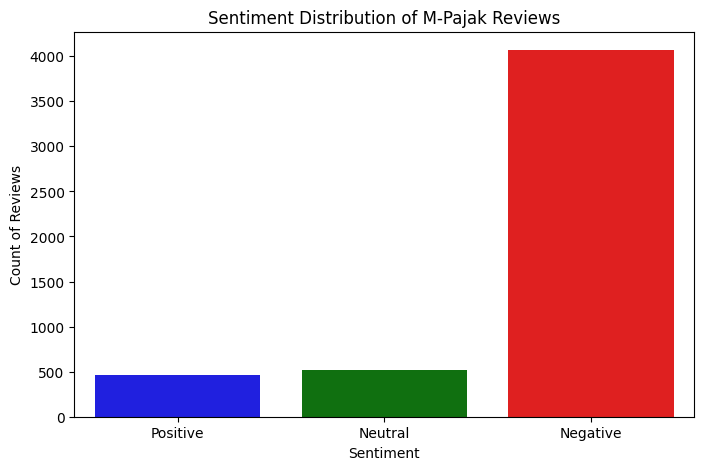

In [42]:
plt.figure(figsize=(8, 5))
custom_palette = {'Positive': 'blue', 'Neutral': 'green', 'Negative': 'red'}
sns.countplot(x='sentiment', data=df, palette=custom_palette, order=[
    'Positive', 'Neutral', 'Negative'], hue='sentiment', legend=False)
plt.title('Sentiment Distribution of M-Pajak Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Count of Reviews')

plt.show()

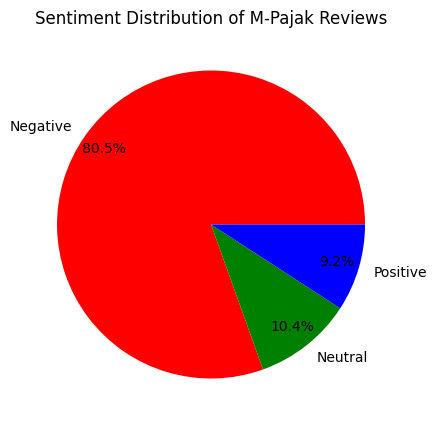

In [43]:
sentiment_counts = df['sentiment'].value_counts()
custom_pie_colors = {'Negative': 'red', 'Neutral': 'green', 'Positive': 'blue'}

# Ensure colors are in the same order as value_counts() output
pie_colors_ordered = [custom_pie_colors[s] for s in sentiment_counts.index]

plt.figure(figsize=(5, 5))
sentiment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=pie_colors_ordered,
    pctdistance=0.85 # Adjust percentage distance to be inside the slices
)
plt.ylabel('') # Hide the 'count' label from the pie chart
plt.title('Sentiment Distribution of M-Pajak Reviews')
plt.show()

## WorldCloud Positive

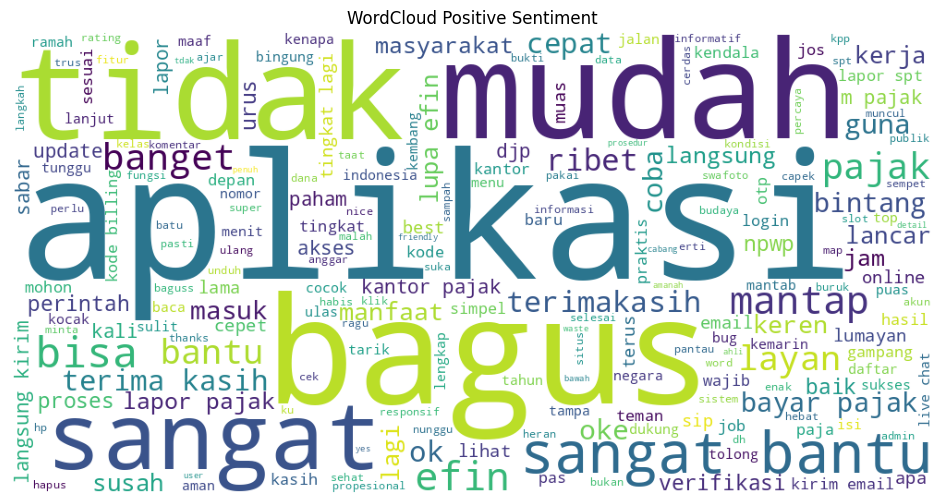

In [44]:
from wordcloud import WordCloud

positive_text = " ".join(
    df[df['sentiment']=="Positive"]['stemming']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud Positive Sentiment")
plt.show()

## WorldCloud Negative

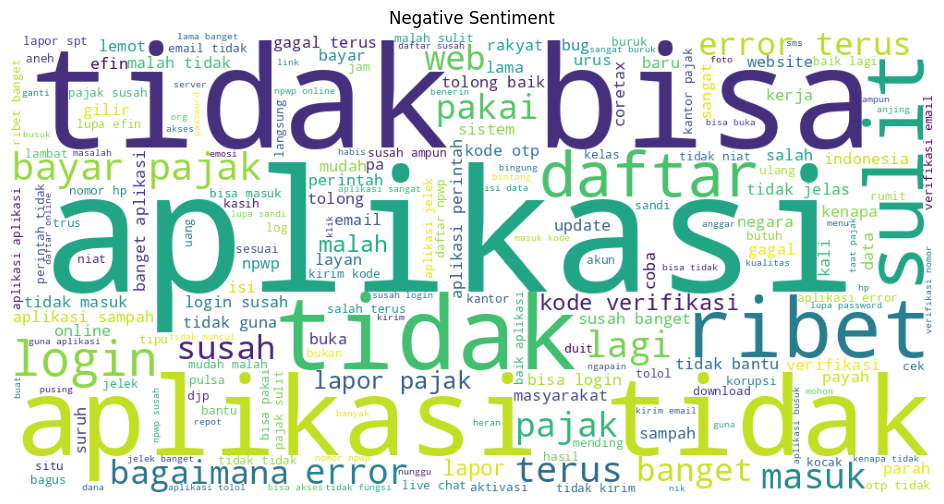

In [45]:
negative_text = " ".join(
    df[df['sentiment']=="Negative"]['stemming']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Sentiment")
plt.show()

## Top 20 Frequent Words

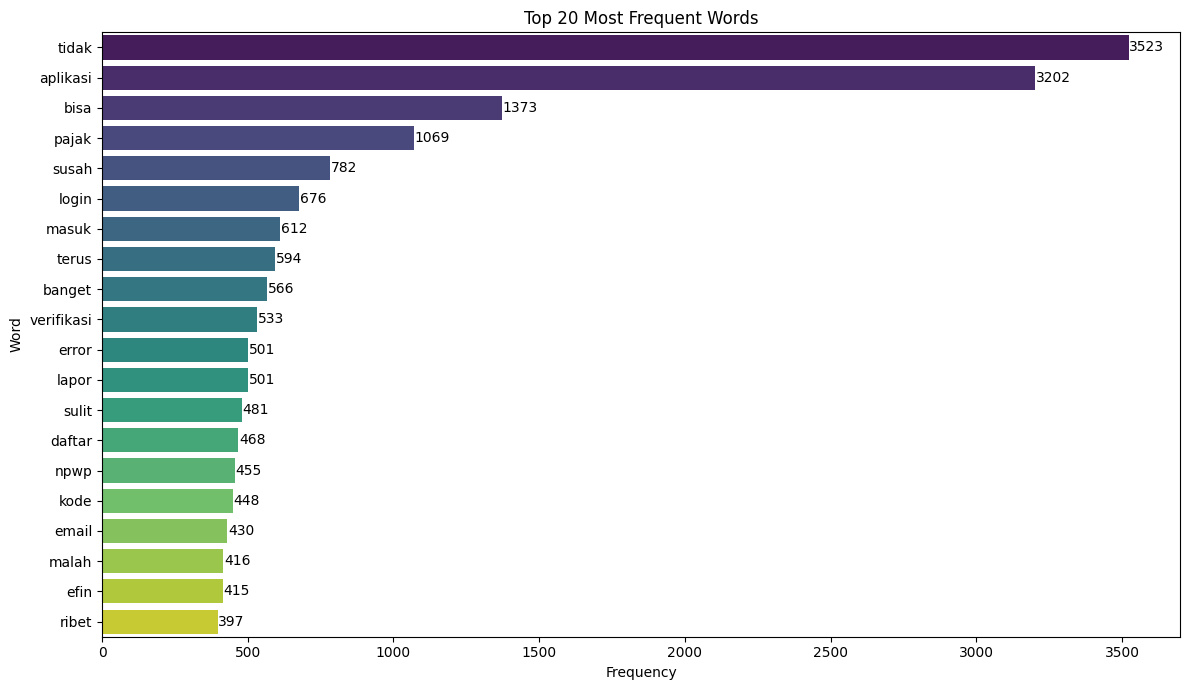

In [46]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

words = ' '.join(df['stemming']).split()

top_words = pd.DataFrame(
    Counter(words).most_common(20),
    columns=['Word', 'Frequency']
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=top_words,
    x='Frequency',
    y='Word',
    hue='Word',
    palette='viridis',
    dodge=False,
    legend=False
)

for i, v in enumerate(top_words['Frequency']):
    plt.text(v + 2, i, str(v), va='center')

plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

## Bigram Sentiment Comparation

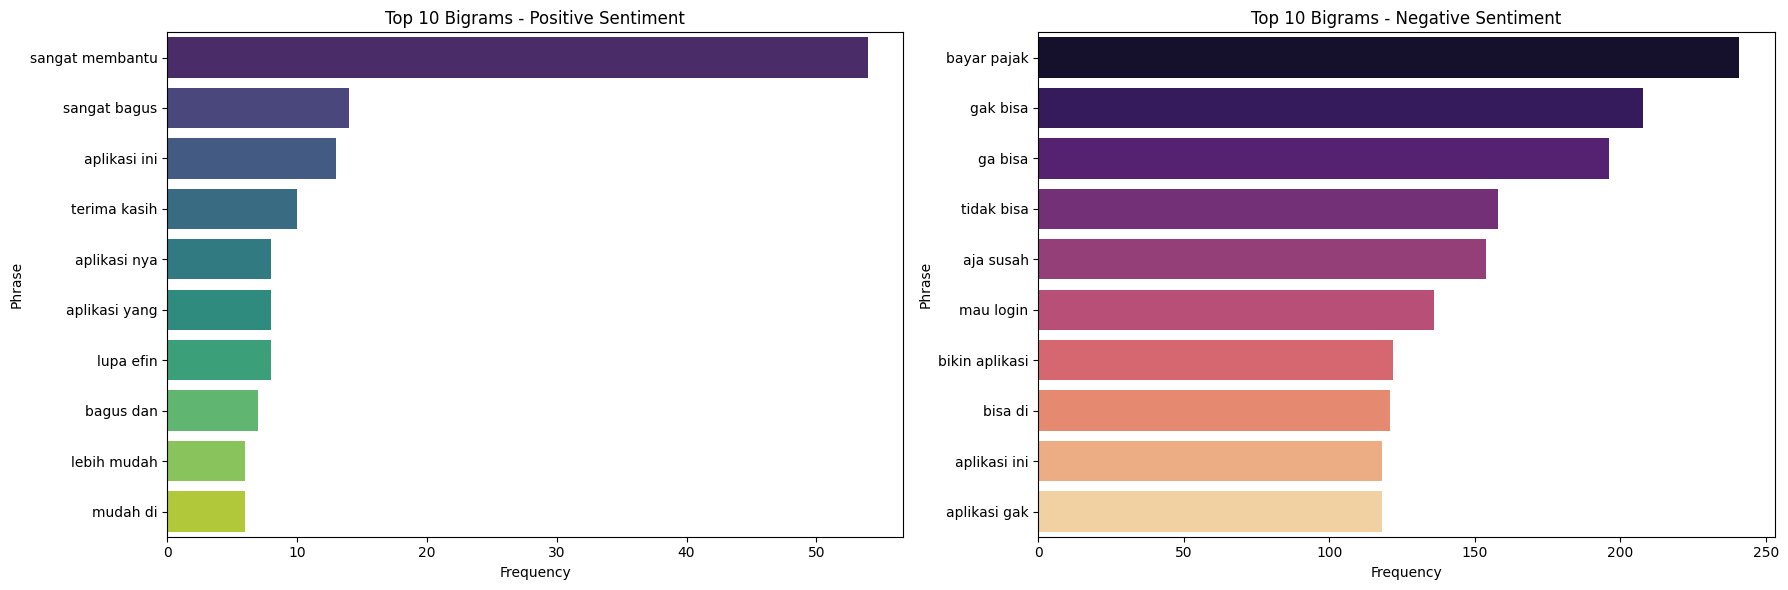

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

def get_top_bigrams(corpus, n=10):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:n], columns=['Phrase', 'Frequency'])

# Persiapan data
pos_data = df[df['sentiment'] == 'Positive']['content'].astype(str)
neg_data = df[df['sentiment'] == 'Negative']['content'].astype(str)

# Plotting Bigrams
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='Frequency', y='Phrase', data=get_top_bigrams(pos_data), ax=axes[
    0], palette='viridis', hue='Phrase', legend=False)
axes[0].set_title('Top 10 Bigrams - Positive Sentiment')

sns.barplot(x='Frequency', y='Phrase', data=get_top_bigrams(neg_data), ax=axes[
    1], palette='magma', hue='Phrase', legend=False)
axes[1].set_title('Top 10 Bigrams - Negative Sentiment')

plt.tight_layout()
plt.show()

## Trigram Sentiment Comparation

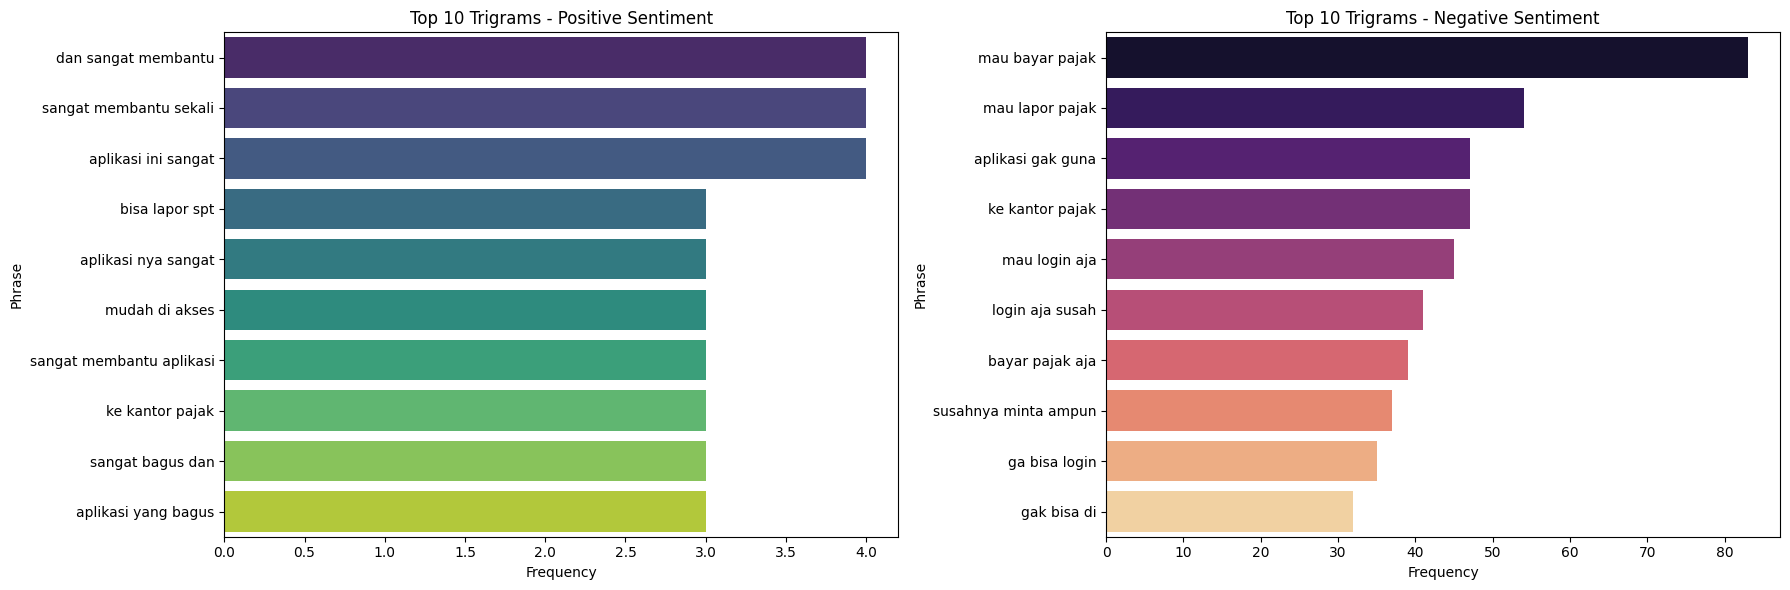

In [48]:
def get_top_trigrams(corpus, n=10):
    vec = CountVectorizer(ngram_range=(3, 3)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:n], columns=['Phrase', 'Frequency'])

# Plotting Trigrams
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='Frequency', y='Phrase', data=get_top_trigrams(pos_data), ax=axes[
    0], palette='viridis', hue='Phrase', legend=False)
axes[0].set_title('Top 10 Trigrams - Positive Sentiment')

sns.barplot(x='Frequency', y='Phrase', data=get_top_trigrams(neg_data), ax=axes[
    1], palette='magma', hue='Phrase', legend=False)
axes[1].set_title('Top 10 Trigrams - Negative Sentiment')

plt.tight_layout()
plt.show()

## Sentiment Trend Over Time - Line Chart

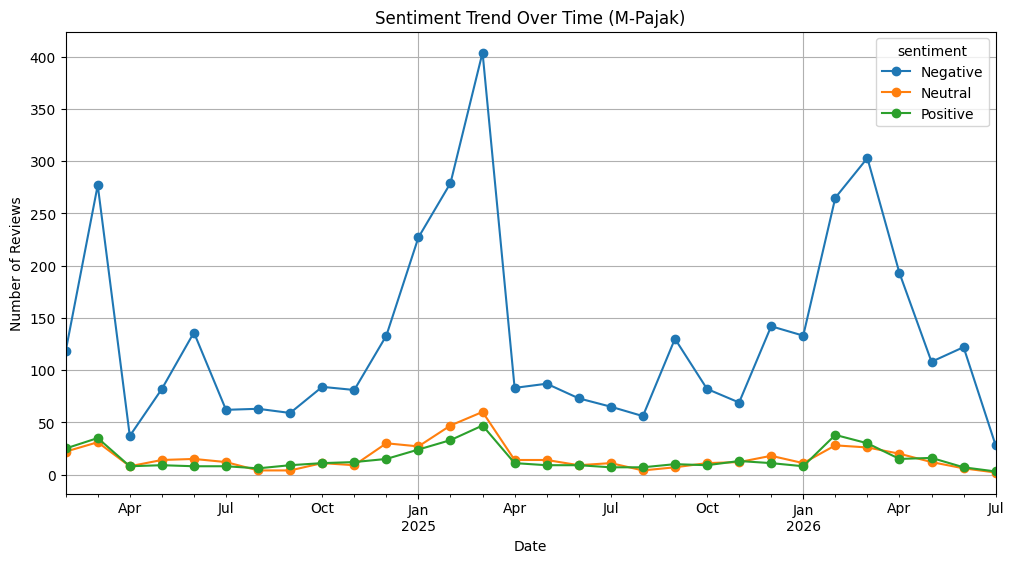

In [49]:
if 'date' not in df.columns:

    temp_df_at = df_playstore[['content', 'at']].drop_duplicates(subset=['content'])
    df = pd.merge(df, temp_df_at, on='content', how='left')
    df.rename(columns={'at': 'date'}, inplace=True)

# Pastikan kolom date adalah datetime
df['date'] = pd.to_datetime(df['date'])

# Mengelompokkan berdasarkan bulan dan sentimen
# Mengoreksi 'label' menjadi 'sentiment' karena itu adalah nama kolom hasil analisis sentimen.
trend = df.groupby([df['date'].dt.to_period('M'), 'sentiment']).size().unstack().fillna(0)

# Plotting
trend.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Sentiment Trend Over Time (M-Pajak)')
plt.ylabel('Number of Reviews')
plt.xlabel('Date')
plt.grid(True)
plt.show()

## Review Length Distribution - Box Plot

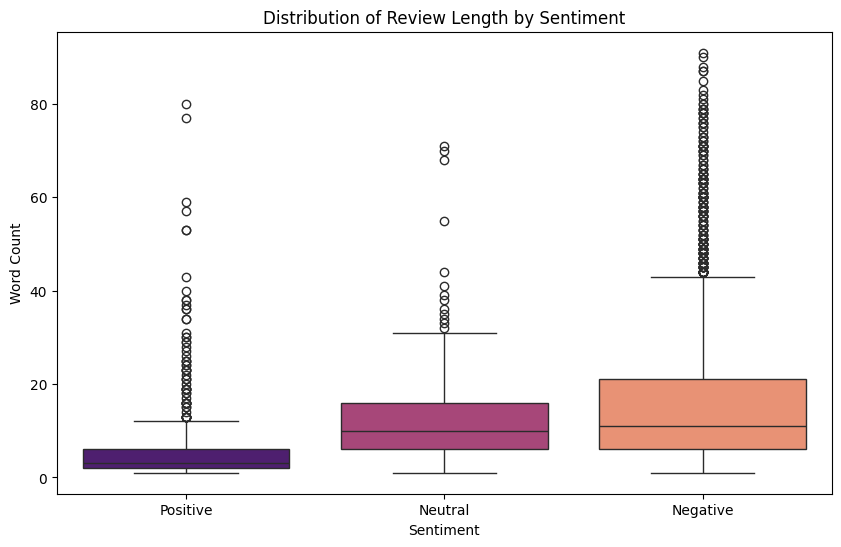

In [50]:
# Membuat kolom baru jumlah kata
df['review_length'] = df['content'].apply(lambda x: len(str(x).split()))

# Plotting Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='review_length', data=df, palette='magma', hue='sentiment', legend=False)
plt.title('Distribution of Review Length by Sentiment')
plt.ylabel('Word Count')
plt.xlabel('Sentiment')
plt.show()

## Model Confidence Score - Histogram

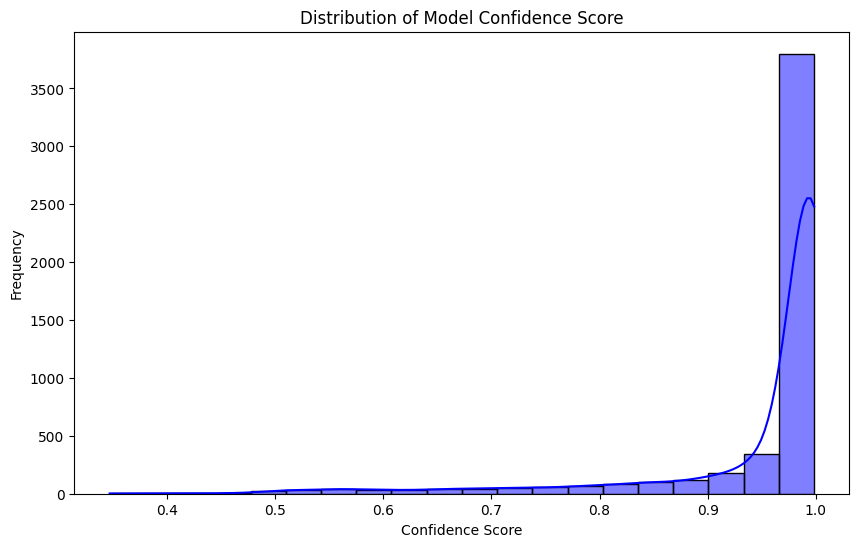

In [51]:
# Plotting Distribution of Confidence Scores
plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment_score'], bins=20, kde=True, color='blue')
plt.title('Distribution of Model Confidence Score')
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.show()

# Split Data

In [52]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(
    df['stemming'], df['sentiment'], test_size=0.2, random_state=42,
    stratify=df['sentiment']
)

stratify=df['sentiment'] agar data terdistribusi dengan adil sehingga tidak ada bias dalam pengujian

# Feature Engineering

TfidfVectorizer: Memberikan bobot lebih pada kata-kata yang unik dan informatif, dibanding CountVectorizer yang hanya menghitung frekuensi biasa. Ini menunjukkan pemahaman Anda tentang optimasi fitur

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)   # unigram + bigram
)

X_train = vectorizer.fit_transform(train_data)
X_test = vectorizer.transform(test_data)

# Cek hasil
print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print(vectorizer.get_feature_names_out()[:20])

Shape X_train: (4044, 5000)
Shape X_test : (1012, 5000)
['aap tidak' 'abad' 'abad niat' 'abai' 'abai kerja' 'abal' 'abal abal'
 'abal belit' 'abal dikit' 'abal korupsi' 'abal tidak' 'abala'
 'abala abalan' 'abalan' 'abis' 'abisin' 'abisin anggar' 'acau'
 'acau tidak' 'ad']


#Modeling

## Naive Bayes

In [54]:
nb = MultinomialNB()
nb.fit(X_train, train_labels)
predictions = nb.predict(X_test)
accuracy = accuracy_score(test_labels, predictions)
report = classification_report(test_labels, predictions)
print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{report}")

Accuracy: 0.8260869565217391
Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      1.00      0.90       814
     Neutral       0.00      0.00      0.00       105
    Positive       1.00      0.24      0.38        93

    accuracy                           0.83      1012
   macro avg       0.61      0.41      0.43      1012
weighted avg       0.75      0.83      0.76      1012



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Logistic Regression

In [55]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, train_labels)
predictions = lr.predict(X_test)
accuracy = accuracy_score(test_labels, predictions)
report = classification_report(test_labels, predictions)
print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{report}")

Accuracy: 0.8438735177865613
Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.99      0.91       814
     Neutral       0.57      0.11      0.19       105
    Positive       0.86      0.41      0.55        93

    accuracy                           0.84      1012
   macro avg       0.76      0.50      0.55      1012
weighted avg       0.82      0.84      0.81      1012



## Support Vector Classification (SVC)

In [56]:
#from sklearn.svm import SVC
#from sklearn.metrics import accuracy_score, classification_report

# Membuat model SVM
#svc = SVC(kernel='linear', random_state=42)

# Training model
#svc.fit(X_train, train_labels)

# Prediksi
#predictions = svc.predict(X_test)

# Evaluasi
#accuracy = accuracy_score(test_labels, predictions)
#report = classification_report(test_labels, predictions)

#print(f"Accuracy: {accuracy}")
#print(f"Classification Report:\n{report}")

In [57]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model Support Vector Machine
svc = LinearSVC(random_state=42)

# Training model
svc.fit(X_train, train_labels)

# Prediksi data testing
predictions = svc.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(test_labels, predictions)
report = classification_report(test_labels, predictions)

# Menampilkan hasil evaluasi
print(f'Accuracy: {accuracy:.4f}\n')
print('Classification Report:')
print(report)

Accuracy: 0.8488

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.96      0.92       814
     Neutral       0.46      0.23      0.31       105
    Positive       0.80      0.56      0.66        93

    accuracy                           0.85      1012
   macro avg       0.71      0.58      0.63      1012
weighted avg       0.83      0.85      0.83      1012



## Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, train_labels)
predictions = rf.predict(X_test)
accuracy = accuracy_score(test_labels, predictions)
report = classification_report(test_labels, predictions)
print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{report}")

Accuracy: 0.8547430830039525
Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.97      0.92       814
     Neutral       0.52      0.12      0.20       105
    Positive       0.70      0.71      0.71        93

    accuracy                           0.85      1012
   macro avg       0.70      0.60      0.61      1012
weighted avg       0.83      0.85      0.83      1012



## Decision Tree

In [59]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, train_labels)
predictions = dt.predict(X_test)
accuracy = accuracy_score(test_labels, predictions)
report = classification_report(test_labels, predictions)
print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{report}")

Accuracy: 0.8181818181818182
Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.99      0.90       814
     Neutral       0.00      0.00      0.00       105
    Positive       0.63      0.26      0.37        93

    accuracy                           0.82      1012
   macro avg       0.49      0.42      0.42      1012
weighted avg       0.72      0.82      0.76      1012



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## ADA Boost

In [60]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, train_labels)
predictions = ada.predict(X_test)
accuracy = accuracy_score(test_labels, predictions)
report = classification_report(test_labels, predictions)
print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{report}")

Accuracy: 0.8191699604743083
Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      1.00      0.90       814
     Neutral       0.00      0.00      0.00       105
    Positive       0.94      0.16      0.28        93

    accuracy                           0.82      1012
   macro avg       0.58      0.39      0.39      1012
weighted avg       0.74      0.82      0.75      1012



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Model Evaluation

## Tabel Perbandingan Metrik

In [61]:
from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

results = []
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "LinearSVC": svc,
    "Naive Bayes": nb,
    "ADA Boost": ada
}

for name, model in models.items():
  pred = model.predict(X_test)

  results.append({
      "Model": name,
      "Accuracy": accuracy_score(test_labels, pred),
      "Precision": precision_score(test_labels, pred, average='weighted'),
      "Recall": recall_score(test_labels, pred, average='weighted'),
      "F1 Score": f1_score(test_labels, pred, average='weighted'),
      })

comparison_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
comparison_df.round(4)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
3,LinearSVC,0.8488,0.8251,0.8488,0.8293
2,Random Forest,0.8547,0.8264,0.8547,0.8264
0,Logistic Regression,0.8439,0.8215,0.8439,0.8052
4,Naive Bayes,0.8261,0.7532,0.8261,0.7610
1,Decision Tree,0.8182,0.7220,0.8182,0.7570
5,ADA Boost,0.8192,0.7435,0.8192,0.7488


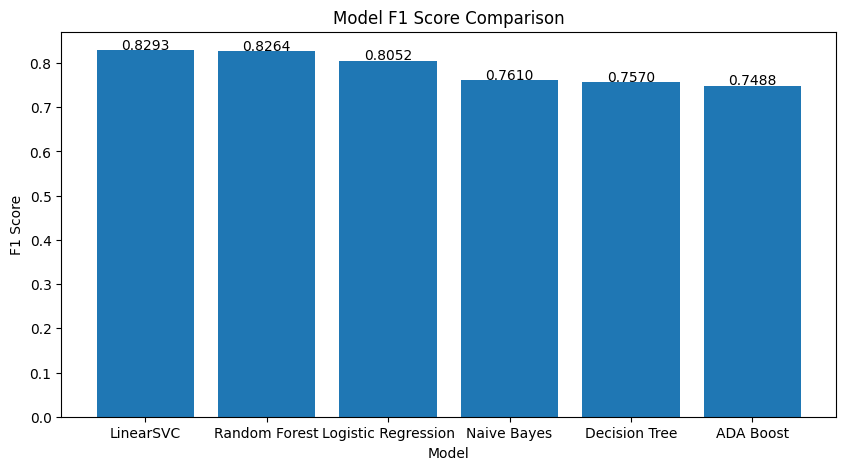

In [62]:
plt.figure(figsize=(10,5))

plt.bar(comparison_df['Model'], comparison_df['F1 Score'])

plt.title("Model F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)

for i, v in enumerate(comparison_df['F1 Score']):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center')

plt.show()

## Confusion Matrix Heatmap Visualization

Accuracy: 0.8488

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.96      0.92       814
     Neutral       0.46      0.23      0.31       105
    Positive       0.80      0.56      0.66        93

    accuracy                           0.85      1012
   macro avg       0.71      0.58      0.63      1012
weighted avg       0.83      0.85      0.83      1012



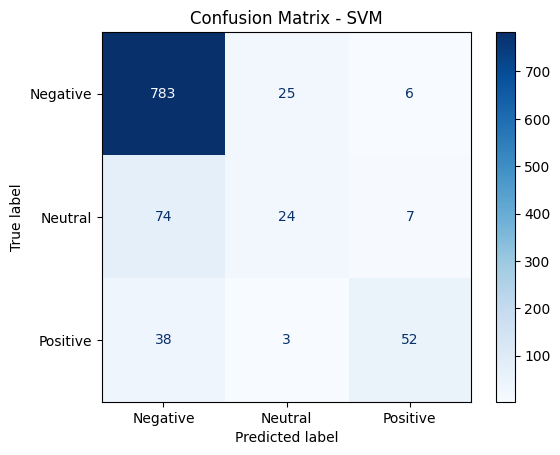

In [63]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Prediksi SVM
pred_svm = svc.predict(X_test)

# Accuracy
accuracy = accuracy_score(test_labels, pred_svm)
print(f"Accuracy: {accuracy:.4f}\n")

# Precision, Recall, F1-score
print("Classification Report:")
print(classification_report(test_labels, pred_svm))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    svc,
    X_test,
    test_labels,
    cmap="Blues"
)

plt.title("Confusion Matrix - SVM")
plt.show()

# Implementasi: Kalibrasi vs Non-Kalibrasi

In [64]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# 1. Base Model (Non-Kalibrasi)
base_svm = LinearSVC(random_state=42, dual="auto")
base_svm.fit(X_train, train_labels)

# 2. Calibrated Model
calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method='sigmoid',
    cv=5
)
calibrated_svm.fit(X_train, train_labels)

CalibratedClassifierCV(cv=5, estimator=LinearSVC(random_state=42))

# Evaluation After Calibration

Accuracy Calibrated SVM: 0.8538

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.97      0.92       814
     Neutral       0.51      0.20      0.29       105
    Positive       0.80      0.56      0.66        93

    accuracy                           0.85      1012
   macro avg       0.73      0.58      0.62      1012
weighted avg       0.83      0.85      0.83      1012



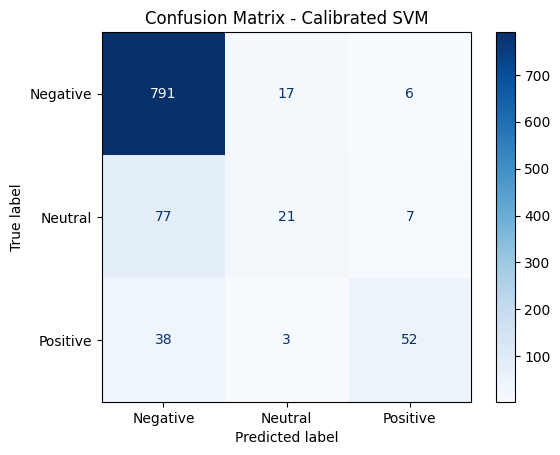

In [65]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Prediksi menggunakan Calibrated SVM
pred_calibrated = calibrated_svm.predict(X_test)

# Accuracy
accuracy_calibrated = accuracy_score(
    test_labels,
    pred_calibrated
)

print(f"Accuracy Calibrated SVM: {accuracy_calibrated:.4f}\n")

# Precision, Recall, F1-Score, dan Support
print("Classification Report:")
print(
    classification_report(
        test_labels,
        pred_calibrated
    )
)

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    calibrated_svm,
    X_test,
    test_labels,
    cmap="Blues"
)

plt.title("Confusion Matrix - Calibrated SVM")
plt.show()

# Evaluasi: Membuktikan Model "Terkalibrasi"

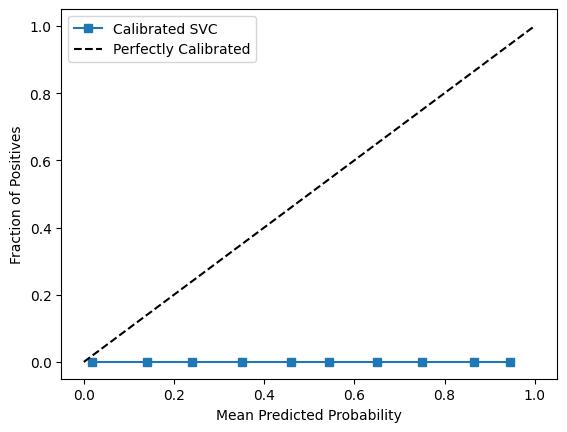

In [66]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'positive' is the last class, its index should be 2 (0-indexed)
prob_pos = calibrated_svm.predict_proba(X_test)[:, 2]

# Create binary labels: 1 for 'positive', 0 for others
binary_test_labels = (test_labels == 'positive').astype(int)

# Now call calibration_curve with the binary labels
fraction_of_positives, mean_predicted_value = calibration_curve(
    binary_test_labels,
    prob_pos,
    n_bins=10,
    pos_label=1 # pos_label should be 1 for binary labels
)

plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Calibrated SVC")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend()
plt.show()

# Transparansi: Feature Traceability

In [67]:
def get_processing_steps(text):
    steps = {}

    # 1. Clean
    cleaned = cleaning_func(text)
    steps['Cleaning'] = cleaned

    # 2. Normalize
    norm = normalize_func(cleaned)
    steps['Normalization'] = norm

    # 3. Stopwords
    sw = stopword_func(norm)
    steps['Stopwords Removal'] = sw

    # 4. Stemming
    steps['Stemming'] = stemming_func(sw)

    return steps

# Deploy

In [68]:
import joblib
import os

# 1. Simpan model SVM yang sudah dikalibrasi (atau model SVM standar)
joblib.dump(calibrated_svm, 'svm_calibrated_model.pkl')
joblib.dump(svc, 'svm_model.pkl')

# 2. Simpan TF-IDF Vectorizer
joblib.dump(vectorizer, 'tfidf.pkl')

print("Model dan TF-IDF berhasil disimpan!")

# 3. Cek apakah file .pkl sudah benar-benar ada di direktori Colab
print("\nFile .pkl yang ada di direktori saat ini:")
for file in os.listdir('.'):
    if file.endswith('.pkl'):
        print(f"- {file}")

Model dan TF-IDF berhasil disimpan!

File .pkl yang ada di direktori saat ini:
- svm_model.pkl
- tfidf.pkl
- svm_calibrated_model.pkl
